In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

In [2]:
#2.  Load dataset (space-separated)
data = pd.read_csv("german_credit_numeric.csv", sep='\s+', header=None)

In [3]:
data.shape

(1000, 25)

In [4]:
# Column names for German Credit Numeric dataset
data.columns = [
    'checking_account_status',
    'duration_months',
    'credit_history',
    'purpose',
    'credit_amount',
    'savings_account',
    'employment_duration',
    'installment_rate',
    'personal_status_sex',
    'other_debtors',
    'present_residence',
    'property',
    'age',
    'other_installment_plans',
    'housing',
    'existing_credits',
    'job',
    'people_liable',
    'telephone',
    'foreign_worker',
    'extra_1',
    'extra_2',
    'extra_3',
    'extra_4',
    'target'
]

# Check head
data.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,personal_status_sex,other_debtors,...,existing_credits,job,people_liable,telephone,foreign_worker,extra_1,extra_2,extra_3,extra_4,target
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2


In [5]:
data['target'].value_counts()

1    700
2    300
Name: target, dtype: int64

In [6]:
#conversion into binary
data['target'] = data['target'].map({1:1, 2:0})

In [7]:
#conversion confirmation

data['target'].value_counts() 

1    700
0    300
Name: target, dtype: int64

In [8]:
#data validation and  as expected 0 missing values 

print(data.shape)
print(data.isnull().sum())

(1000, 25)
checking_account_status    0
duration_months            0
credit_history             0
purpose                    0
credit_amount              0
savings_account            0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
extra_1                    0
extra_2                    0
extra_3                    0
extra_4                    0
target                     0
dtype: int64


In [9]:
# Split Data 

from sklearn.model_selection import train_test_split

X = data.drop('target', axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

#stratify=y ensures the 70/30 class distribution stays balanced.

In [10]:
# Training Random forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [11]:
# Predict probabilities 

pred_prob = rf.predict_proba(X_test)[:,1]

AUC: 0.7837301587301587


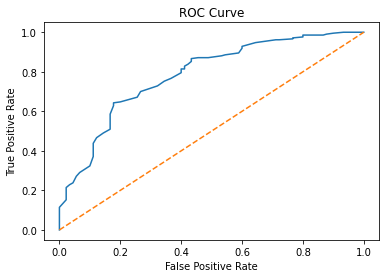

In [12]:
# AUC Score

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, pred_prob)
print("AUC:", auc) 

#ROC curve 

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, pred_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [13]:
# KS Statistic
# Install dependencies if needed
# %pip install pandas scikit-learn matplotlib scipy

!pip install scipy

In [14]:
from scipy.stats import ks_2samp
import scipy
print(scipy.__version__)

1.5.0


In [15]:
#compute KS statistic 

# Probabilities for each class
good = pred_prob[y_test == 1]
bad = pred_prob[y_test == 0]

ks_stat, p_value = ks_2samp(good, bad)

print("KS Statistic:", ks_stat)

KS Statistic: 0.4650793650793651


KS: 0.46507936507936504


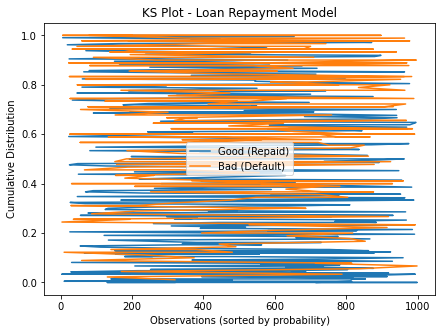

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Sort probabilities
df_ks = pd.DataFrame({
    'prob': pred_prob,
    'target': y_test
})

df_ks = df_ks.sort_values(by='prob')

# cumulative distributions
df_ks['cum_good'] = np.cumsum(df_ks['target']==1)/sum(df_ks['target']==1)
df_ks['cum_bad'] = np.cumsum(df_ks['target']==0)/sum(df_ks['target']==0)

# KS value
ks = max(abs(df_ks['cum_good'] - df_ks['cum_bad']))
print("KS:", ks)

# Plot
plt.figure(figsize=(7,5))
plt.plot(df_ks['cum_good'], label='Good (Repaid)')
plt.plot(df_ks['cum_bad'], label='Bad (Default)')
plt.title('KS Plot - Loan Repayment Model')
plt.ylabel('Cumulative Distribution')
plt.xlabel('Observations (sorted by probability)')
plt.legend()

plt.show()

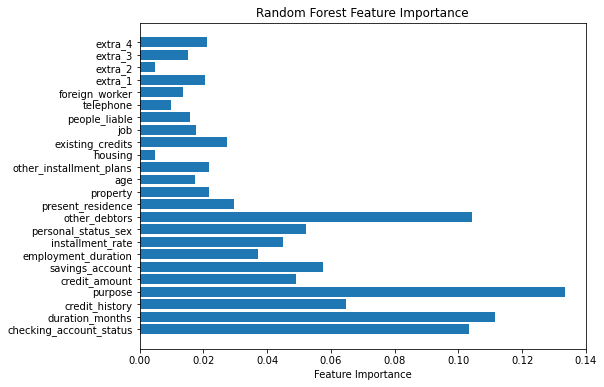

In [18]:
#feature importance

import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8,6))
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")

plt.savefig('images/feature_importance.png', bbox_inches='tight')
plt.show()